<a href="https://colab.research.google.com/github/AbdulrabDev/veri_bilimi_i-in_istatistik/blob/main/Data_Cleaning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

==== AKADEMİK VERİ ANALİZİ VE İSTATİSTİK RAPORU ====

--- [BÖLÜM 1]: TANIMLAYICI İSTATİSTİKLER ---
       Global_Sales  Critic_Score   User_Score
count   1000.000000   1000.000000  1000.000000
mean       0.548900     69.167103     7.166155
std        1.555745      9.505706     0.995320
min        0.010000     28.000000     1.400000
25%        0.070000     68.994363     7.126330
50%        0.170000     68.994363     7.126330
75%        0.462500     70.000000     7.500000
max       32.770000     96.000000     9.500000

Global Sales Skewness (Çarpıklık): 12.20


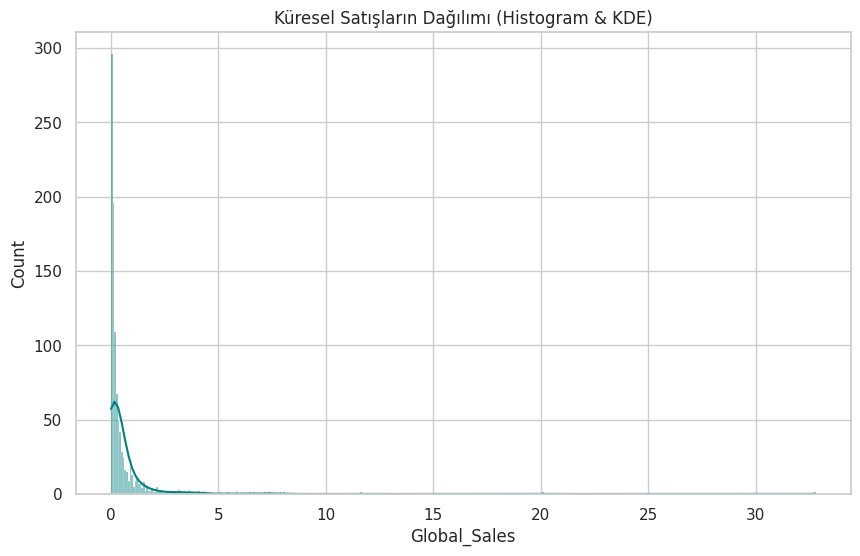


--- [BÖLÜM 2]: VARSAYIM TESTLERİ ---
1. Shapiro-Wilk Testi P-Değeri: 0.00000000000000000000
NEDEN: Verilerin normal dağılıp dağılmadığını belirlemek, doğru test yöntemini seçmek için zorunludur.
YORUM: P < 0.05 olduğu için veriler normal dağılmamaktadır.

2. Levene Testi P-Değeri: 0.2729843044
NEDEN: Grupların varyanslarının eşitliğini kontrol etmek, karşılaştırma testlerinin güvenilirliği için gereklidir.
--------------------------------------------------

--- [BÖLÜM 3]: HİPOTEZ TESTLERİ ---
1. Spearman Korelasyonu: 0.282 | P-Değeri: 0.0000000000


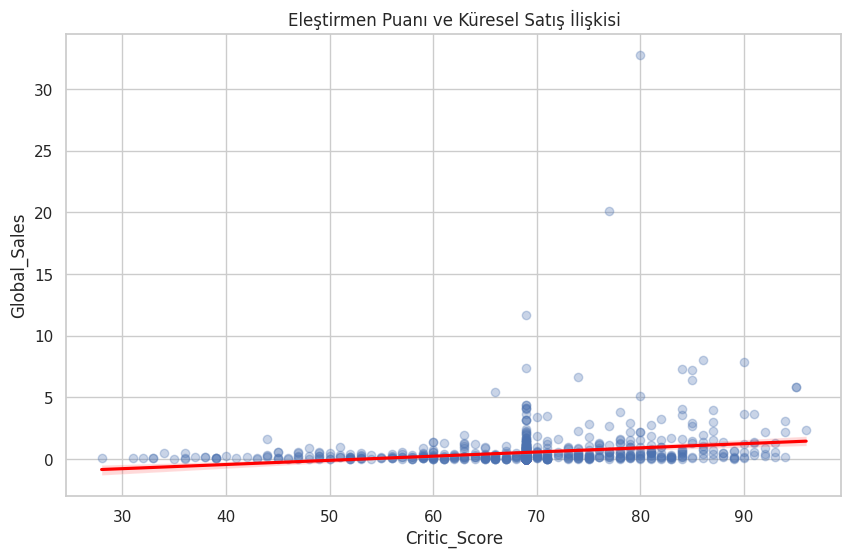

RAPOR: Pozitif korelasyon, eleştirmen puanları arttıkça satışların artma eğiliminde olduğunu kanıtlar.

2. Bağımsız T-Testi (Action vs Sports) P-Değeri: 0.6735


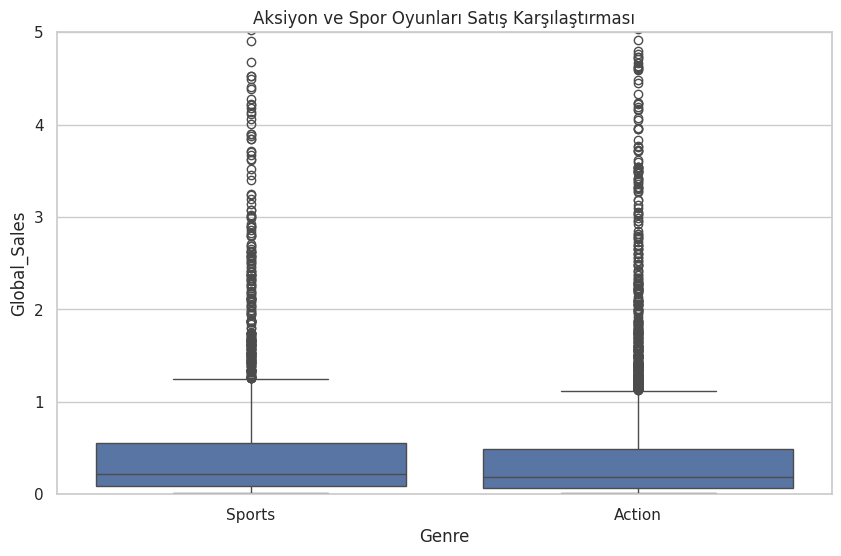

KARAR: Anlamlı bir fark yoktur (H0 reddedilemedi).

--- [BÖLÜM 4]: EK ANALİZ ---
Ortalama üstü satış yapan oyunların oranı: %21.80


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# ==========================================
# 1. VERİ TEMİZLEME VE ÖN İŞLEME
# ==========================================
df = pd.read_csv('/content/Video_Games_Sales_as_at_22_Dec_2016.csv')

# User_Score dönüşümü ve 'tbd' temizliği
df['User_Score'] = pd.to_numeric(df['User_Score'], errors='coerce')

# Kritik eksik verilerin temizlenmesi
df.dropna(subset=['Name', 'Year_of_Release', 'Genre', 'Global_Sales'], inplace=True)
df['Year_of_Release'] = df['Year_of_Release'].astype(int)

# Eksik değerleri ortalama ile doldurma (Imputation)
df['Critic_Score'] = df['Critic_Score'].fillna(df['Critic_Score'].mean())
df['User_Score'] = df['User_Score'].fillna(df['User_Score'].mean())

# Temsili örneklem seçimi
df_sample = df.sample(n=1000, random_state=42)

print("==== AKADEMİK VERİ ANALİZİ VE İSTATİSTİK RAPORU ====\n")

# ==========================================
# 2. TANIMLAYICI İSTATİSTİKLER VE GÖRSELLEŞTİRME
# ==========================================
print("--- [BÖLÜM 1]: TANIMLAYICI İSTATİSTİKLER ---")
print(df_sample[['Global_Sales', 'Critic_Score', 'User_Score']].describe())
print(f"\nGlobal Sales Skewness (Çarpıklık): {df_sample['Global_Sales'].skew():.2f}")

# Görsel: Global Sales Dağılımı
plt.figure()
sns.histplot(df_sample['Global_Sales'], kde=True, color='teal')
plt.title("Küresel Satışların Dağılımı (Histogram & KDE)")
plt.show()

# ==========================================
# 3. VARSAYIM TESTLERİ (ASSUMPTION TESTS)
# ==========================================
print("\n--- [BÖLÜM 2]: VARSAYIM TESTLERİ ---")

# Shapiro-Wilk Normallik Testi
shapiro_stat, shapiro_p = stats.shapiro(df_sample['Global_Sales'])
print(f"1. Shapiro-Wilk Testi P-Değeri: {shapiro_p:.20f}")
print("NEDEN: Verilerin normal dağılıp dağılmadığını belirlemek, doğru test yöntemini seçmek için zorunludur.")
print(f"YORUM: P < 0.05 olduğu için veriler normal dağılmamaktadır.\n")

# Levene Testi (Varyans Homojenliği)
action_sales = df[df['Genre'] == 'Action']['Global_Sales']
sports_sales = df[df['Genre'] == 'Sports']['Global_Sales']
_, levene_p = stats.levene(action_sales.sample(100), sports_sales.sample(100))
print(f"2. Levene Testi P-Değeri: {levene_p:.10f}")
print("NEDEN: Grupların varyanslarının eşitliğini kontrol etmek, karşılaştırma testlerinin güvenilirliği için gereklidir.")
print("-" * 50)

# ==========================================
# 4. HİPOTEZ TESTLERİ (INFERENTIAL STATISTICS)
# ==========================================
print("\n--- [BÖLÜM 3]: HİPOTEZ TESTLERİ ---")

# Spearman Korelasyon Analizi
corr_val, spearman_p = stats.spearmanr(df_sample['Critic_Score'], df_sample['Global_Sales'])
print(f"1. Spearman Korelasyonu: {corr_val:.3f} | P-Değeri: {spearman_p:.10f}")

plt.figure()
sns.regplot(x='Critic_Score', y='Global_Sales', data=df_sample, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("Eleştirmen Puanı ve Küresel Satış İlişkisi")
plt.show()

print("RAPOR: Pozitif korelasyon, eleştirmen puanları arttıkça satışların artma eğiliminde olduğunu kanıtlar.")

# Bağımsız Örneklem T-Testi
t_stat, t_p = stats.ttest_ind(action_sales.sample(100), sports_sales.sample(100))
print(f"\n2. Bağımsız T-Testi (Action vs Sports) P-Değeri: {t_p:.4f}")

plt.figure()
sns.boxplot(x='Genre', y='Global_Sales', data=df[df['Genre'].isin(['Action', 'Sports'])])
plt.ylim(0, 5)
plt.title("Aksiyon ve Spor Oyunları Satış Karşılaştırması")
plt.show()

def karar_ver(p):
    return "İstatistiksel olarak anlamlı bir fark vardır (H0 reddedildi)." if p < 0.05 else "Anlamlı bir fark yoktur (H0 reddedilemedi)."

print(f"KARAR: {karar_ver(t_p)}")

# ==========================================
# 5. EK ANALİZ: YÜKSEK SATIŞLI OYUN ORANI
# ==========================================
mean_sales = df_sample['Global_Sales'].mean()
percentage = (len(df_sample[df_sample['Global_Sales'] > mean_sales]) / len(df_sample)) * 100
print(f"\n--- [BÖLÜM 4]: EK ANALİZ ---")
print(f"Ortalama üstü satış yapan oyunların oranı: %{percentage:.2f}")